# 🌱 Drone AI Agriculture - Model Training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Xybronix/drone-ai-agriculture/blob/main/ml/notebooks/training_colab.ipynb)

This notebook trains the agricultural classification model for:
- 🌿 Plant Detection
- 🪴 Species Identification
- 📈 Growth Stage Evaluation
- 🏥 Health Diagnosis

**Requirements:** GPU runtime recommended (Runtime → Change runtime type → T4 GPU)"

## 1. Environment Setup

In [ ]:
# Check GPU availability
!nvidia-smi

In [ ]:
# Clone the repository
!git clone https://github.com/Xybronix/drone-ai-agriculture.git
%cd drone-ai-agriculture

In [ ]:
# Install dependencies
!pip install -q tensorflow==2.19.0 albumentations kaggle tf2onnx onnx pillow tqdm

In [ ]:
# Verify TensorFlow and GPU
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

## 2. Kaggle Configuration

To download datasets from Kaggle, you need to configure your API credentials.

### Option A: Using Colab Secrets (Recommended)
1. Click the 🔑 icon in the left sidebar
2. Add two secrets:
   - `KAGGLE_USERNAME`: Your Kaggle username
   - `KAGGLE_KEY`: Your Kaggle API key

### Option B: Upload kaggle.json\n",
1. Go to https://www.kaggle.com/settings
2. Click \"Create New Token\" to download kaggle.json
3. Upload it when prompted below

In [ ]:
import os

# Try to get credentials from Colab secrets
try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Kaggle credentials loaded from Colab secrets")
except Exception as e:
    print(f"⚠️ Could not load from secrets: {e}")
    print("Please upload your kaggle.json file:")

    from google.colab import files
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ kaggle.json configured")

## 3. Download Dataset

In [ ]:
# List available datasets
!python ml/download_datasets.py --list

In [ ]:
# Download PlantVillage dataset (recommended for training)
# This may take a few minutes depending on your connection
# !python ml/download_datasets.py --download plantvillage
!python ml/download_datasets.py --download-all

In [ ]:
# Alternative: Download mini dataset for quick testing
# !python ml/download_datasets.py --download mini_dataset

In [ ]:
# Verify the dataset

print("Verification of combined datasets  :")
!python ml/download_datasets.py --verify combined_dataset

## 4. Explore the Dataset

In [18]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

# Set dataset path
# DATASET_PATH = Path('./data/datasets/plantvillage')

# If using mini dataset:
# DATASET_PATH = Path('./data/datasets/mini_dataset')

# If using combined dataset:
DATASET_PATH = Path('../../data/datasets/combined_dataset')

# Get class names
class_names = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
print(f"Found {len(class_names)} classes:")
for i, name in enumerate(class_names[:10]):
    print(f"  {i+1}. {name}")
if len(class_names) > 10:
    print(f"  ... and {len(class_names) - 10} more")

Found 25 classes:
  1. Black-grass
  2. Charlock
  3. Cleavers
  4. Common Chickweed
  5. Common wheat
  6. Fat Hen
  7. Loose Silky-bent
  8. Maize
  9. Pepper__bell___Bacterial_spot
  10. Pepper__bell___healthy
  ... and 15 more


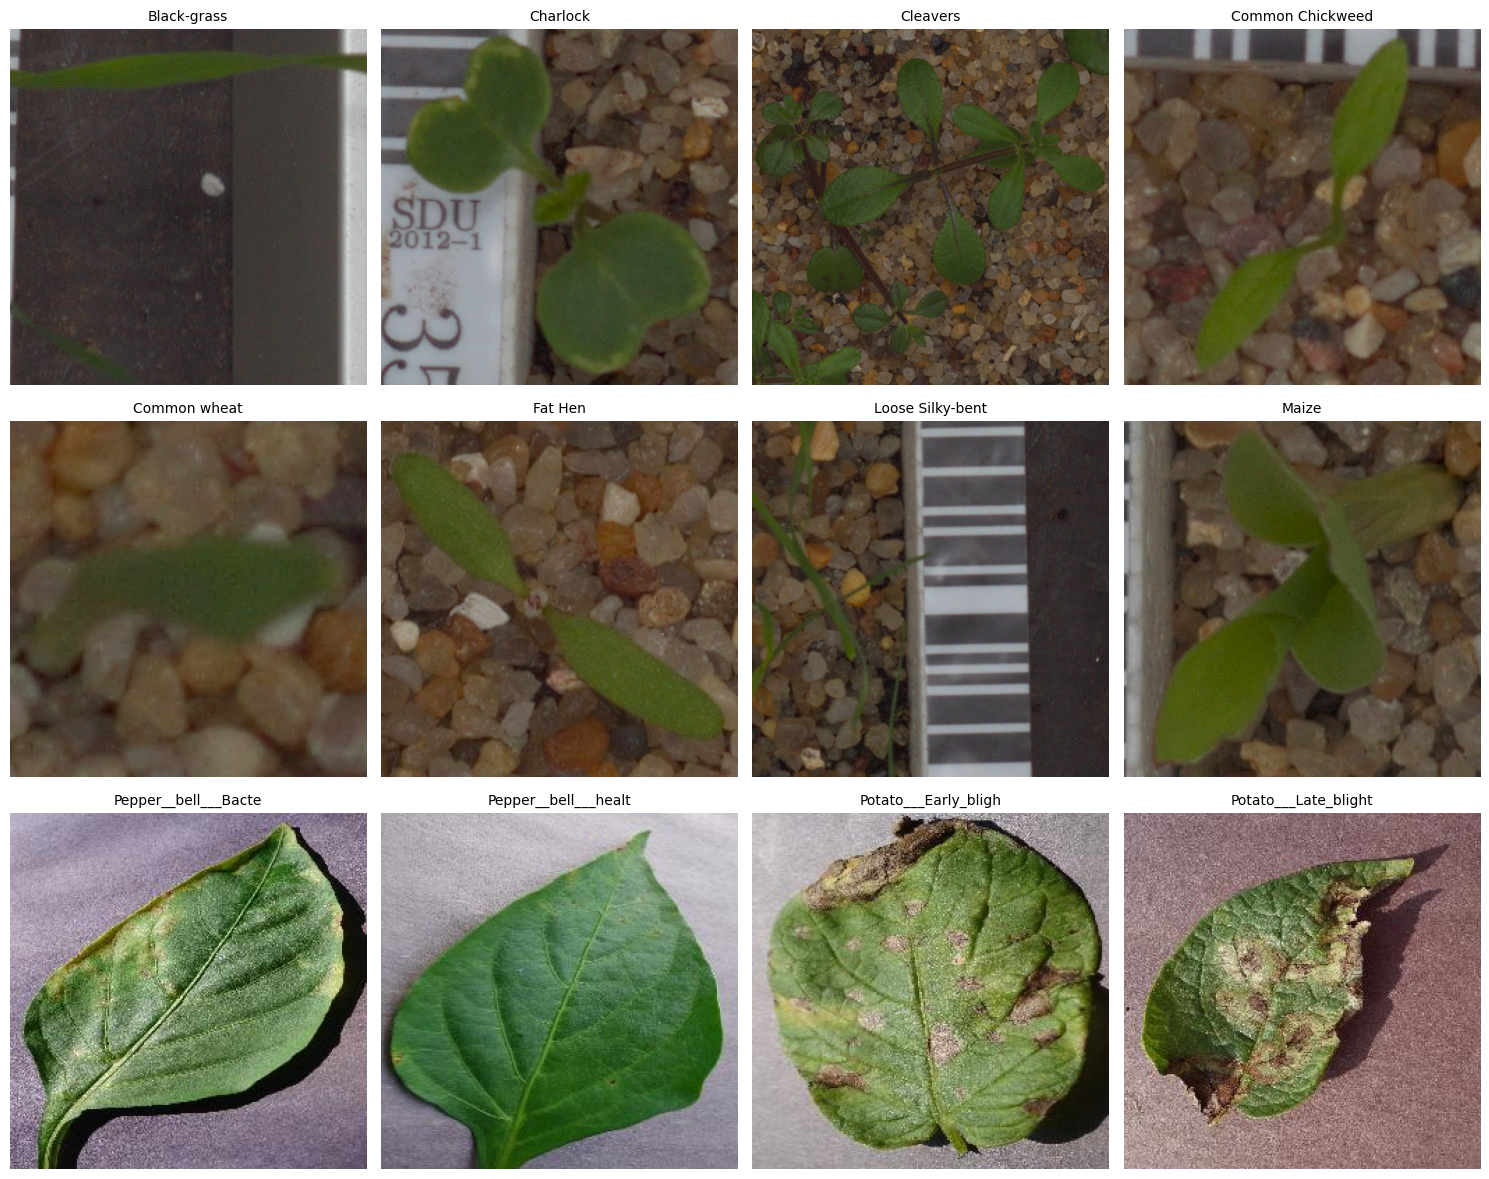

In [19]:
# Visualize sample images
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(class_names):
        class_dir = DATASET_PATH / class_names[i]
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG')) + list(class_dir.glob('*.png'))
        if images:
            img_path = random.choice(images)
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(class_names[i][:20], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Configure Training

In [29]:
# Training configuration
CONFIG = {
    'dataset_path': str(DATASET_PATH),
    'output_dir': './output',
    'model_name': 'agriculture_model',
    'backbone': 'efficientnet',  # or 'mobilenet'
    'epochs': 5,
    'fine_tune_epochs': 5,
    'batch_size': 16,
    'learning_rate': 1e-4,
    'image_size': (224, 224),
    'validation_split': 0.2,
}

print("Training Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Training Configuration:
  dataset_path: ..\..\data\datasets\combined_dataset
  output_dir: ./output
  model_name: agriculture_model
  backbone: efficientnet
  epochs: 5
  fine_tune_epochs: 5
  batch_size: 16
  learning_rate: 0.0001
  image_size: (224, 224)
  validation_split: 0.2


## 6. Train the Model

In [30]:
# Run training using the training script
!python ../../ml/train_model.py \
    --dataset {CONFIG['dataset_path']} \
    --output {CONFIG['output_dir']} \
    --model-name {CONFIG['model_name']} \
    --backbone {CONFIG['backbone']} \
    --epochs {CONFIG['epochs']} \
    --fine-tune-epochs {CONFIG['fine_tune_epochs']} \
    --batch-size {CONFIG['batch_size']} \
    --learning-rate {CONFIG['learning_rate']}

2026-01-09 11:59:17,972 - INFO - Preparing datasets for analysis...
c:\Users\PC\Documents\drone-ai-agriculture\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-01-09 11:59:39,506 - INFO - Loading dataset from ..\..\data\datasets\combined_dataset
2026-01-09 11:59:41.670070: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 11:59:43,918 - INFO - Found classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___La

Found 20148 files belonging to 25 classes.
Using 16119 files for training.
Found 20148 files belonging to 25 classes.
Using 4029 files for validation.

TRAINING PROBLEM ANALYSIS

1. Class Distribution Analysis:
   Training samples analyzed: 640
   Validation samples analyzed: 320

   Classes with potential issues:
   ⚠️  Black-grass: Only 9 training samples
   ⚠️  Maize: Only 7 training samples
   ⚠️  Potato___healthy: Only 8 training samples
   ⚠️  ShepherdΓÇÖs Purse: Only 6 training samples

2. Data Quality Check:
   Image value range: [0.000, 0.979]
   Image mean: 0.435
   ✓ Images properly normalized [0, 1]
   ✓ Labels properly one-hot encoded (sum to ~1)

3. Recommendations:
   • Increase patience to 15-20 epochs
   • Reduce dropout to 0.2-0.3
   • Use smaller batch size (16)
   • Disable mixed precision for debugging
   • Consider class weighting if imbalance > 10:1

Found 20148 files belonging to 25 classes.
Using 16119 files for training.
Found 20148 files belonging to 25 class

## 7. Evaluate Results

In [26]:
# Load training summary
import json

with open('./output/training_summary.json', 'r') as f:
    summary = json.load(f)

print("="*60)
print("TRAINING RESULTS")
print("="*60)
print(f"Model: {summary['model_name']}")
print(f"Backbone: {summary['backbone']}")
print(f"Classes: {summary['num_classes']}")
print(f"\nFinal Metrics:")
for metric, value in summary['final_metrics'].items():
    print(f"  {metric}: {value:.4f}")
print("="*60)

TRAINING RESULTS
Model: agriculture_model
Backbone: efficientnet
Classes: 25

Final Metrics:
  accuracy: 0.0482
  auc: 0.4768
  loss: 3.3280
  top3_accuracy: 0.1047


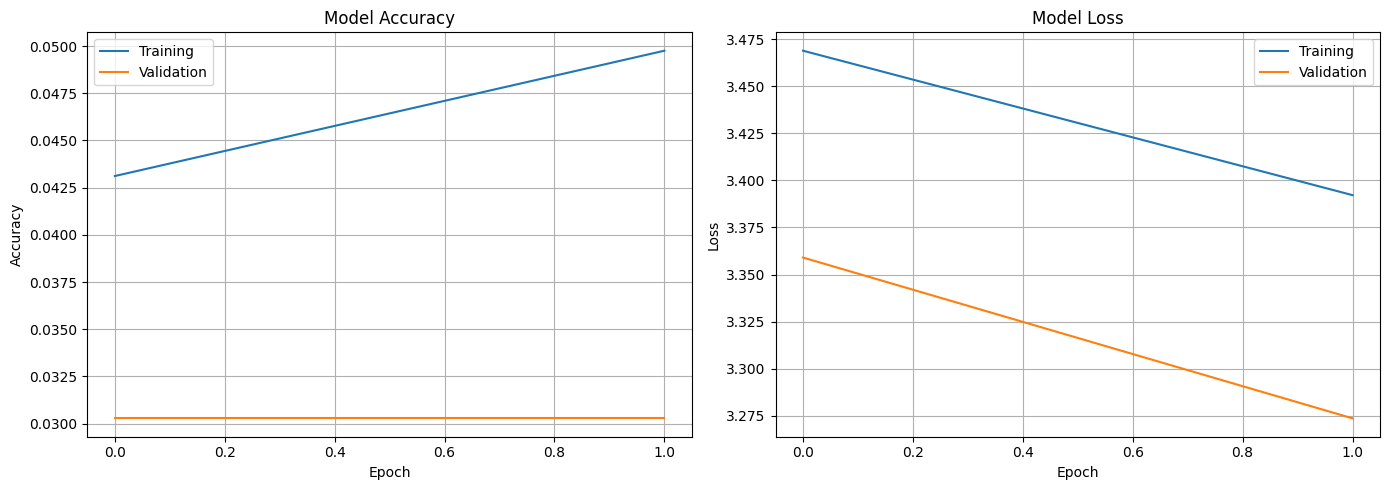

In [27]:
# Plot training history
import pandas as pd

history_df = pd.read_csv('./output/logs/training_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_df['accuracy'], label='Training')
axes[0].plot(history_df['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_df['loss'], label='Training')
axes[1].plot(history_df['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('./output/training_curves.png', dpi=150)
plt.show()

## 8. Test the Model

In [32]:
# Load the trained model
from tensorflow import keras
import numpy as np

model = keras.models.load_model('./output/models/agriculture_model.keras')

# Load class names
with open('./output/models/class_names.json', 'r') as f:
    class_names = json.load(f)

print(f"Model loaded with {len(class_names)} classes")

Model loaded with 25 classes


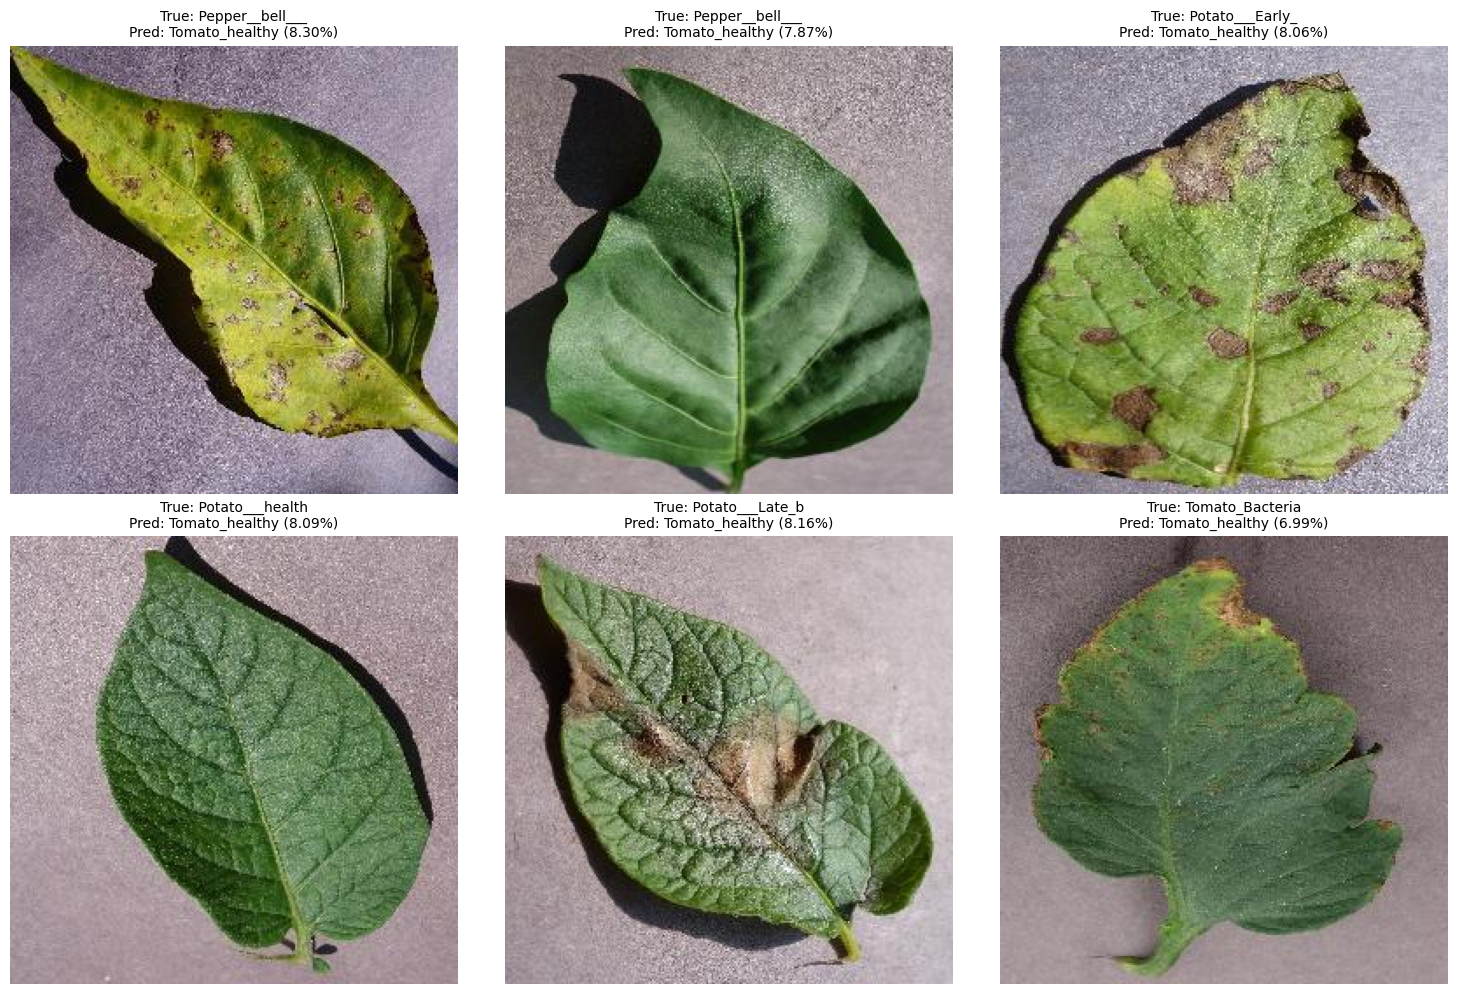

In [33]:
# Test on random images
def predict_image(image_path):
    img = keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array, verbose=0)
    top_idx = np.argsort(predictions[0])[::-1][:3]

    return [(class_names[i], predictions[0][i]) for i in top_idx]

# Get random test images
test_images = []
for class_dir in DATASET_PATH.iterdir():
    if class_dir.is_dir():
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG'))
        if images:
            test_images.append(random.choice(images))

# Display predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:6]):
    if i < len(test_images):
        img_path = test_images[i]
        img = Image.open(img_path)
        predictions = predict_image(img_path)

        ax.imshow(img)
        title = f"True: {img_path.parent.name[:15]}\n"
        title += f"Pred: {predictions[0][0][:15]} ({predictions[0][1]:.2%})"
        ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Export Model

In [ ]:
# List exported models
!ls -lh ./output/models/

In [ ]:
# Download model files
from google.colab import files

# Create a zip of all output files
!zip -r model_export.zip ./output/models/ ./output/training_summary.json ./output/training_curves.png

files.download('model_export.zip')
print("\n✅ Model exported! Upload the .h5 or .onnx file to your cloud API.")

## 10. Next Steps

1. **Deploy the model**: Upload `agriculture_model.h5` or `agriculture_model.onnx` to your cloud API
2. **Test the API**: Use the web interface to test image analysis
3. **Improve accuracy**: Try different backbones, more data, or longer training

### Files to download:
- `agriculture_model.h5` - TensorFlow/Keras model
- `agriculture_model.onnx` - ONNX model (faster inference)
- `class_names.json` - Class labels mapping
- `training_summary.json` - Training configuration and results